## 1. Load Dataset and Import libraries

In [21]:
import sys
from pathlib import Path

_here = Path.cwd()
PROJECT_ROOT = next(
    (p for p in [_here] + list(_here.parents) if (p / 'config.py').exists()),
    _here
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from config import PROJECT_ROOT, DATA_DIR, RAW_DIR, PROCESSED_DIR, SPLITS_DIR

MODELS_DIR    = PROJECT_ROOT / 'models'
NOTEBOOKS_DIR = PROJECT_ROOT / 'notebooks'


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


X_train = pd.read_csv(SPLITS_DIR / 'train_features.csv')
y_train = pd.read_csv(SPLITS_DIR / 'train_target.csv')
X_val = pd.read_csv(SPLITS_DIR / 'val_features.csv')
y_val = pd.read_csv(SPLITS_DIR / 'val_target.csv')
X_test = pd.read_csv(SPLITS_DIR / 'test_features.csv')
y_test = pd.read_csv(SPLITS_DIR / 'test_target.csv')
y_val_orig = pd.read_csv(SPLITS_DIR / 'val_target_original.csv')








## 1b. Encode categorical features

In [23]:
object_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
label_encoders = {}

for col in object_cols:
    le = LabelEncoder()
    parts = [X_train[col], X_val[col]]
    if col in X_test.columns:
        parts.append(X_test[col])
    combined = pd.concat(parts, ignore_index=True).astype(str)
    le.fit(combined)

    X_train[col] = le.transform(X_train[col].astype(str)).astype(np.int32)
    X_val[col]   = le.transform(X_val[col].astype(str)).astype(np.int32)
    if col in X_test.columns:
        X_test[col] = le.transform(X_test[col].astype(str)).astype(np.int32)

    label_encoders[col] = le
    print(f"  {col}: {len(le.classes_)} labels -> 0..{len(le.classes_) - 1}")

rest = X_train.select_dtypes(include=["object"]).columns.tolist()
if rest:
    raise ValueError(f"Still has object columns: {rest}")

print(f"\nLabelEncoded {len(object_cols)} cols | "
      f"X_train {X_train.shape} | X_val {X_val.shape} | X_test {X_test.shape}")


  date: 1684 labels -> 0..1683
  family: 33 labels -> 0..32
  type: 5 labels -> 0..4
  city: 22 labels -> 0..21
  state: 16 labels -> 0..15
  store_family: 1782 labels -> 0..1781

LabelEncoded 6 cols | X_train (2918916, 49) | X_val (55242, 49) | X_test (26730, 49)


## 2. XGBoost Training

In [4]:
model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=100,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    objective="reg:squarederror",
    tree_method="hist",
    early_stopping_rounds=100,
)

model.fit(
    X_train, y_train["sales_log"],
    eval_set=[(X_val, y_val["sales_log"])],
    verbose=100,
)


[0]	validation_0-rmse:2.51366
[100]	validation_0-rmse:0.37847
[200]	validation_0-rmse:0.37567
[300]	validation_0-rmse:0.37457
[400]	validation_0-rmse:0.37365
[500]	validation_0-rmse:0.37297
[600]	validation_0-rmse:0.37234
[700]	validation_0-rmse:0.37181
[800]	validation_0-rmse:0.37140
[900]	validation_0-rmse:0.37105
[999]	validation_0-rmse:0.37090


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=100,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=100, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=-1, num_parallel_tree=None, ...)

## 3. Baseline Evaluation ( Before Optuna Tuning)

In [5]:
# ── Helper: regression metrics (RMSLE, RMSE, MAE) ──
y_test_orig = pd.DataFrame()
y_test_orig['sales'] = np.expm1(y_test['sales_log'])


def evaluate_metrics(y_true_log, y_pred_log, y_true_orig, label=""):
    y_pred_orig = np.clip(np.expm1(y_pred_log), 0, None)
    y_true_orig = np.clip(y_true_orig, 0, None)

    rmsle    = np.sqrt(mean_squared_log_error(y_true_orig, y_pred_orig))
    rmse     = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    mae      = mean_absolute_error(y_true_orig, y_pred_orig)
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))

    if label:
        print(f"\nXGBoost — {label}:")
        print(f"  RMSLE              : {rmsle:.6f}")
        print(f"  RMSE (sales units) : {rmse:.6f}")
        print(f"  MAE  (sales units) : {mae:.6f}")
        print(f"  RMSE (log scale)   : {rmse_log:.6f}")

    return {"RMSLE": rmsle, "RMSE": rmse, "MAE": mae, "RMSE_log": rmse_log}

# ── Baseline evaluation on val and test ──
baseline_val  = evaluate_metrics(
    y_val["sales_log"],
    model.predict(X_val),
    y_val_orig["sales"],
    "Baseline — Val"
)

baseline_test = evaluate_metrics(
    y_test["sales_log"],
    model.predict(X_test),
    y_test_orig["sales"],
    "Baseline — Test"
)

baseline_df = pd.DataFrame([baseline_val, baseline_test],
    index=["XGBoost Val", "XGBoost Test"]
)

print("\nBaseline Table: ")
display(baseline_df.round(4))




XGBoost — Baseline — Val:
  RMSLE              : 0.370880
  RMSE (sales units) : 207.353899
  MAE  (sales units) : 52.934139
  RMSE (log scale)   : 0.370899

XGBoost — Baseline — Test:
  RMSLE              : 0.374266
  RMSE (sales units) : 197.042972
  MAE  (sales units) : 56.482537
  RMSE (log scale)   : 0.374282

Baseline Table: 


,RMSLE,RMSE,MAE,RMSE_log
XGBoost Val,0.3709,207.3539,52.9341,0.3709
XGBoost Test,0.3743,197.0430,56.4825,0.3743


## 4. Optuna Tuning

In [6]:
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial):
    params = {
        "n_estimators"        : 1000,
        "learning_rate"       : trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth"           : trial.suggest_int("max_depth", 4, 10),
        "min_child_weight"    : trial.suggest_int("min_child_weight", 20, 300),
        "subsample"           : trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree"    : trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha"           : trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda"          : trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "objective"           : "reg:squarederror",
        "tree_method"         : "hist",
        "early_stopping_rounds": 50,
        "random_state"        : 42,
        "n_jobs"              : -1,
    }

    trial_model = xgb.XGBRegressor(**params)
    trial_model.fit(
        X_train, y_train["sales_log"],
        eval_set=[(X_val, y_val["sales_log"])],
        verbose=False,
    )

    val_preds = trial_model.predict(X_val)
    rmsle = np.sqrt(mean_squared_log_error(
        np.clip(y_val_orig["sales"], 0, None),
        np.clip(np.expm1(val_preds), 0, None)
    ))
    return rmsle

import json
import os
params_file = MODELS_DIR / "xgboost_optuna_best_params.json"
if os.path.exists(params_file):
    print(f"Found {params_file.name}. Skipping Optuna tuning...")
    with open(params_file, "r") as f:
        best_optuna_params = json.load(f)
else:
    print("Starting Optuna tuning...")
    study = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=45, show_progress_bar=True)
    best_optuna_params = study.best_params
    print(f"\nBest RMSLE on val : {study.best_value:.6f}")
    os.makedirs(params_file.parent, exist_ok=True)
    with open(params_file, "w") as f:
        json.dump(best_optuna_params, f)
    print(f"Saved best parameters to {params_file}")

print("\nBest params:")
for k, v in best_optuna_params.items():
    print(f"  {k}: {v}")


  0%|          | 0/45 [00:00<?, ?it/s]


Best RMSLE on val : 0.369081
Best params:
  learning_rate: 0.05661765609380996
  max_depth: 10
  min_child_weight: 62
  subsample: 0.891754215404674
  colsample_bytree: 0.7928782229160452
  reg_alpha: 0.06528187294151135
  reg_lambda: 0.05430278926785755


## 5. Retrain with the tuned parameters

In [7]:
# ── Combine train + val for final retraining ──
X_train_val     = pd.concat([X_train, X_val], ignore_index=True)
y_train_val_log = pd.concat(
    [y_train["sales_log"], y_val["sales_log"]], ignore_index=True
)

# ── Build best params (no early_stopping_rounds — no eval_set) ──
best_params = {
    **best_optuna_params,
    "n_estimators" : 1000,
    "objective"    : "reg:squarederror",
    "tree_method"  : "hist",
    "random_state" : 42,
    "n_jobs"       : -1,
}


import joblib
model_file = MODELS_DIR / "xgboost_tuned_model.pkl"
if os.path.exists(model_file):
    print(f"Found {model_file.name}. Loading model...")
    best_model = joblib.load(model_file)
else:
    print("Retraining model with new parameters...")
    best_model = xgb.XGBRegressor(**best_params)
    best_model.fit(X_train_val, y_train_val_log, verbose=100)
    os.makedirs(model_file.parent, exist_ok=True)
    joblib.dump(best_model, model_file)
    print(f"Saved model to {model_file}")

# ── Post-tuning metrics ──
tuned_val = evaluate_metrics(
    y_val["sales_log"],
    best_model.predict(X_val),
    y_val_orig["sales"],
    "Tuned — Val"
)

tuned_test = evaluate_metrics(
    y_test["sales_log"],
    best_model.predict(X_test),
    y_test_orig["sales"],
    "Tuned — Test"
)


XGBoost — Tuned — Val:
  RMSLE              : 0.331299
  RMSE (sales units) : 171.483915
  MAE  (sales units) : 43.893011
  RMSE (log scale)   : 0.331311

XGBoost — Tuned — Test:
  RMSLE              : 0.370917
  RMSE (sales units) : 190.183397
  MAE  (sales units) : 55.597520
  RMSE (log scale)   : 0.370938


## 6. Comparison

In [8]:
metrics_order = ["RMSLE", "RMSE", "MAE", "RMSE_log"]

summary = pd.DataFrame({
    "Metric"       : metrics_order,
    "Baseline Val" : [baseline_val[m]  for m in metrics_order],
    "Tuned Val"    : [tuned_val[m]     for m in metrics_order],
    "Val Gap"      : [tuned_val[m]  - baseline_val[m]  for m in metrics_order],
    "Baseline Test": [baseline_test[m] for m in metrics_order],
    "Tuned Test"   : [tuned_test[m]    for m in metrics_order],
    "Test Gap"     : [tuned_test[m] - baseline_test[m] for m in metrics_order],
})

print("\nXGBoost — Before vs After Optuna Tuning")
print("=" * 85)
print(summary.to_string(index=False, float_format="{:.6f}".format))
print("=" * 85)
print("Note: Negative Gap = improvement after tuning")


XGBoost — Before vs After Optuna Tuning
  Metric  Baseline Val  Tuned Val    Val Gap  Baseline Test  Tuned Test  Test Gap
   RMSLE      0.370880   0.331299  -0.039581       0.374266    0.370917 -0.003349
    RMSE    207.353899 171.483915 -35.869984     197.042972  190.183397 -6.859574
     MAE     52.934139  43.893011  -9.041128      56.482537   55.597520 -0.885017
RMSE_log      0.370899   0.331311  -0.039588       0.374282    0.370938 -0.003344
Note: Negative Gap = improvement after tuning


## 7. Feature Importance

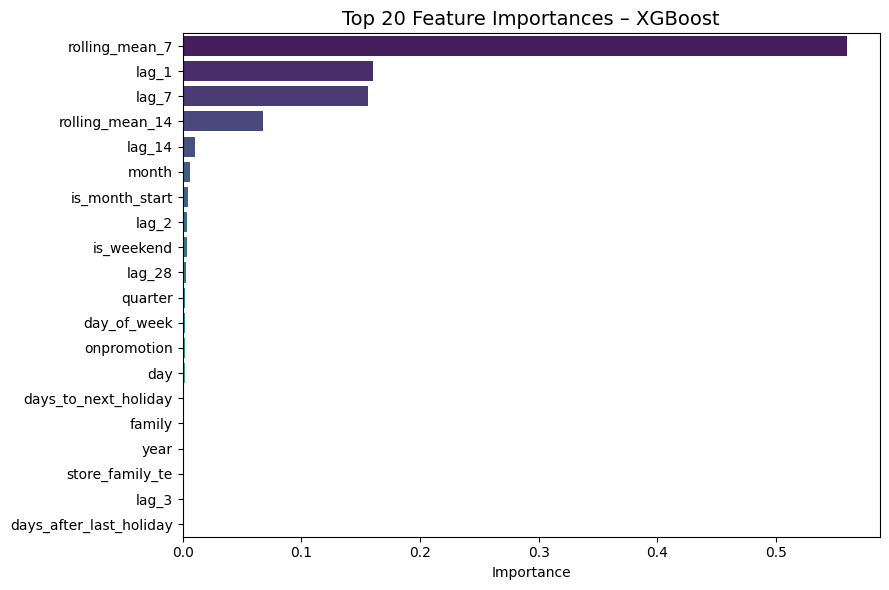


Top 20 features:
                feature  importance
         rolling_mean_7    0.559457
                  lag_1    0.160507
                  lag_7    0.156351
        rolling_mean_14    0.067621
                 lag_14    0.010464
                  month    0.006222
         is_month_start    0.004569
                  lag_2    0.004092
             is_weekend    0.003379
                 lag_28    0.002465
                quarter    0.002333
            day_of_week    0.001956
            onpromotion    0.001808
                    day    0.001671
   days_to_next_holiday    0.001256
                 family    0.001171
                   year    0.001119
        store_family_te    0.001115
                  lag_3    0.000962
days_after_last_holiday    0.000954


In [9]:
importance_df = pd.DataFrame({
    'feature':    X_train.columns,
    'importance': model.feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)

top_n  = 20
top_df = importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(
    data=top_df, x='importance', y='feature',
    hue='feature', palette='viridis', legend=False, ax=ax
)
ax.set_title(f'Top {top_n} Feature Importances – XGBoost', fontsize=14)
ax.set_xlabel('Importance')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print(f"\nTop {top_n} features:")
print(top_df.to_string(index=False))


## 5. Error Analysis

In [28]:
# ── Build val_df: central dataframe for all error analysis ──
y_pred_val      = best_model.predict(X_val)
val_pred_actual = np.maximum(np.expm1(y_pred_val), 0.0)
y_actual        = (y_val_orig["sales"].values
                   if isinstance(y_val_orig, pd.DataFrame)
                   else y_val_orig.values)

date_val = pd.to_datetime(X_val[["year", "month", "day"]])

val_df = pd.DataFrame({
    "date"      : date_val.values,
    "store_nbr" : X_val["store_nbr"].values,
    "family"    : X_val["family"].values,
    "actual"    : y_actual,
    "predicted" : val_pred_actual,
})
val_df["residual"] = val_df["actual"] - val_df["predicted"]


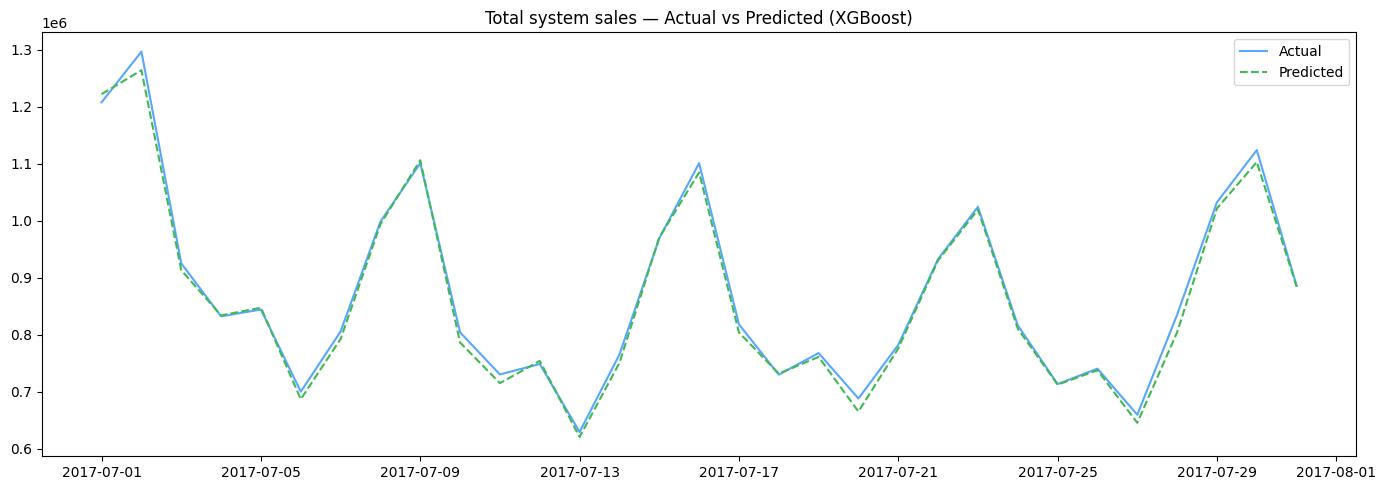

In [29]:
daily = (
    val_df[["date", "actual", "predicted"]]
    .groupby("date").sum()
)

plt.figure(figsize=(14, 5))
plt.plot(daily.index, daily["actual"],    label="Actual",    color="#58a6ff")
plt.plot(daily.index, daily["predicted"], label="Predicted", color="#3fb950", linestyle="--")
plt.title("Total system sales — Actual vs Predicted (XGBoost)")
plt.legend()
plt.tight_layout()
plt.show()


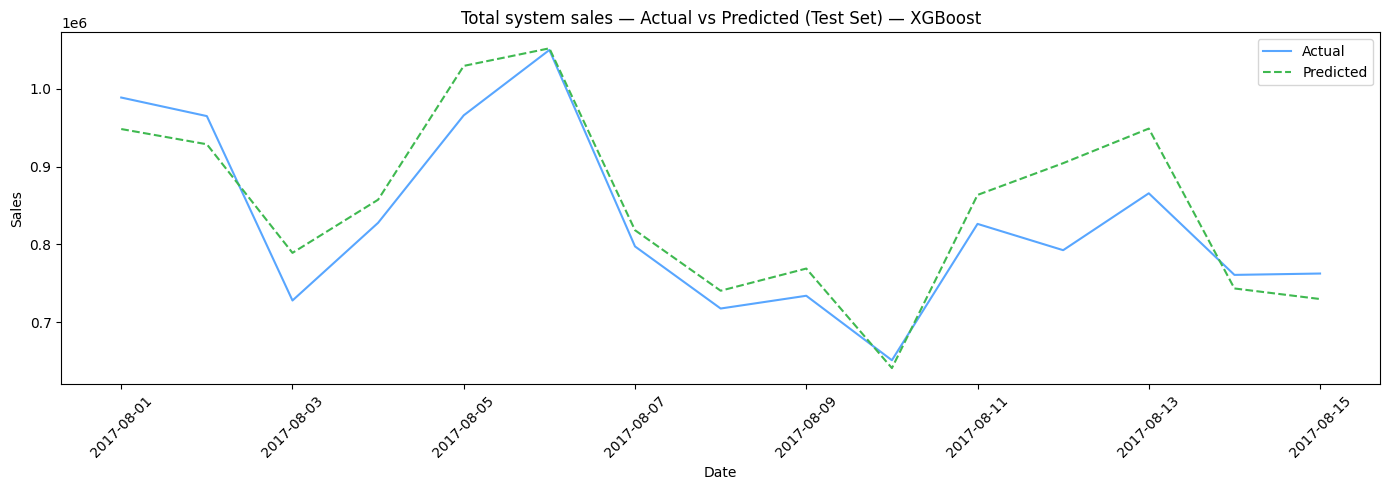

In [30]:
# ── Plot: Total Sales — Actual vs Predicted (Test Set) — XGBoost ──
y_pred_test      = best_model.predict(X_test)
test_pred_actual = np.maximum(np.expm1(y_pred_test), 0.0)

date_test = pd.to_datetime(X_test[["year", "month", "day"]])

test_df = pd.DataFrame({
    "date"      : date_test.values,
    "store_nbr" : X_test["store_nbr"].values,
    "family"    : X_test["family"].values,
    "actual"    : y_test_orig["sales"].values,
    "predicted" : test_pred_actual,
})
test_df["residual"] = test_df["actual"] - test_df["predicted"]

daily_test = test_df[["date", "actual", "predicted"]].groupby("date").sum()

plt.figure(figsize=(14, 5))
plt.plot(daily_test.index, daily_test["actual"],    label="Actual",    color="#58a6ff")
plt.plot(daily_test.index, daily_test["predicted"], label="Predicted", color="#3fb950", linestyle="--")
plt.title("Total system sales — Actual vs Predicted (Test Set) — XGBoost")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Holiday: RMSLE = 0.3211 (7,128 rows)
Non-Holiday: RMSLE = 0.3328 (48,114 rows)


C:\Users\GIGABYTE\AppData\Local\Temp\ipykernel_10568\2054203536.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_hol, x="label", y="rmsle", palette=["#ffa657", "#58a6ff"], ax=ax)


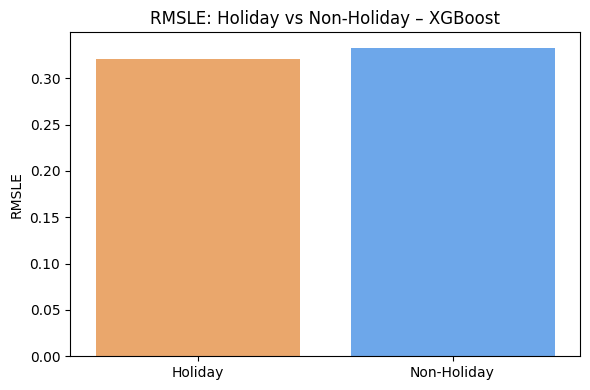

In [35]:
# ── Holiday vs Non-Holiday ──
holidays = pd.read_csv(PROCESSED_DIR / 'holidays_events_cleaned.csv')
holiday_dates        = set(pd.to_datetime(holidays["date"]).dt.strftime("%Y-%m-%d"))
val_df["date_str"]   = pd.to_datetime(val_df["date"]).dt.strftime("%Y-%m-%d")
val_df["is_holiday"] = val_df["date_str"].isin(holiday_dates)

holiday_summary = []
for label, mask in [("Holiday", val_df["is_holiday"]), ("Non-Holiday", ~val_df["is_holiday"])]:
    sub = val_df[mask]
    r   = np.sqrt(mean_squared_log_error(sub["actual"].clip(0), sub["predicted"].clip(0)))
    holiday_summary.append({"label": label, "rmsle": r, "n_rows": int(mask.sum())})
    print(f"{label}: RMSLE = {r:.4f} ({int(mask.sum()):,} rows)")

fig, ax = plt.subplots(figsize=(6, 4))
df_hol = pd.DataFrame(holiday_summary)
sns.barplot(data=df_hol, x="label", y="rmsle", palette=["#ffa657", "#58a6ff"], ax=ax)
ax.set_title("RMSLE: Holiday vs Non-Holiday – XGBoost")
ax.set_xlabel(""); ax.set_ylabel("RMSLE")
plt.tight_layout()
plt.show()


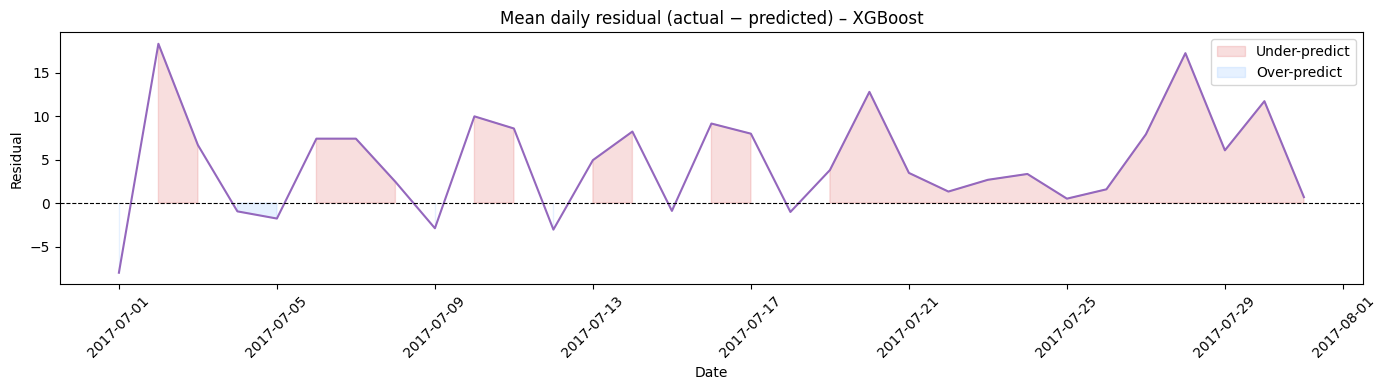

In [32]:
# ── Daily mean residual ──
daily_resid = val_df.groupby("date")["residual"].mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_resid.index, daily_resid.values, color="#9467bd", linewidth=1.5)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.fill_between(daily_resid.index, daily_resid.values, 0,
                where=daily_resid.values > 0, alpha=0.15, color="#d62728", label="Under-predict")
ax.fill_between(daily_resid.index, daily_resid.values, 0,
                where=daily_resid.values < 0, alpha=0.15, color="#58a6ff", label="Over-predict")
ax.set_title("Mean daily residual (actual − predicted) – XGBoost")
ax.set_xlabel("Date"); ax.set_ylabel("Residual")
ax.legend(); plt.xticks(rotation=45); plt.tight_layout()
plt.show()


In [33]:
# ── Summary ──
print("\n" + "="*45)
print("ERROR ANALYSIS SUMMARY — XGBoost")
print("="*45)
print(f"Mean residual  : {val_df['residual'].mean():+.4f}  (+ = under, - = over)")
print(f"Std  residual  : {val_df['residual'].std():.4f}")
print("="*45)



ERROR ANALYSIS SUMMARY — XGBoost
Mean residual  : +4.6952  (+ = under, - = over)
Std  residual  : 171.4212


In [34]:
import joblib
import os

save_dir = NOTEBOOKS_DIR / '08_forecasting'
os.makedirs(save_dir, exist_ok=True)

joblib.dump(best_model, os.path.join(save_dir, 'xgb_best_model.pkl'))
print("Saved: xgb_best_model.pkl")

Saved: xgb_best_model.pkl
